In [15]:
def load_curves(csv_dir, min_pts=20, max_pts=250):
    """
    Same preprocessing as in DBSCAN.ipynb.
    """
    curves_data = []  
    files = os.listdir(csv_dir)
    for fname in tqdm(files, desc="Processing curves"):
        oid = fname.replace(".csv", "")
        df = pd.read_csv(os.path.join(csv_dir, fname))
        g = df[df['fid'] == 1]
        r = df[df['fid'] == 2].sort_values('mjd')
        
        if len(r) < min_pts or len(g) < min_pts or len(r) > max_pts:
            continue
        
        color_offset = g['magpsf'].median() - r['magpsf'].median()
        mag = r['magpsf'].values + color_offset
        t = r['mjd'].values
        
        if np.any(np.isnan(mag)) or np.any(np.isnan(t)):
            continue
        
        # Normalize
        t_norm = (t - t.min()) / (t.max() - t.min() + 1e-9)
        mag_norm = (mag - mag.min()) / (mag.max() - mag.min() + 1e-9)
        
        curves_data.append((oid, t_norm, mag_norm, t, mag, df['ra'][0], df['dec'][0]))
    
    return curves_data

In [24]:
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
from alerce.core import Alerce

csv_dir = "csv_files"

print("=" * 50)
curves_data = load_curves(csv_dir)
print(f"Loaded {len(curves_data)} curves")

Processing curves: 100%|██████████| 12258/12258 [00:34<00:00, 352.65it/s]

Loaded 2869 curves


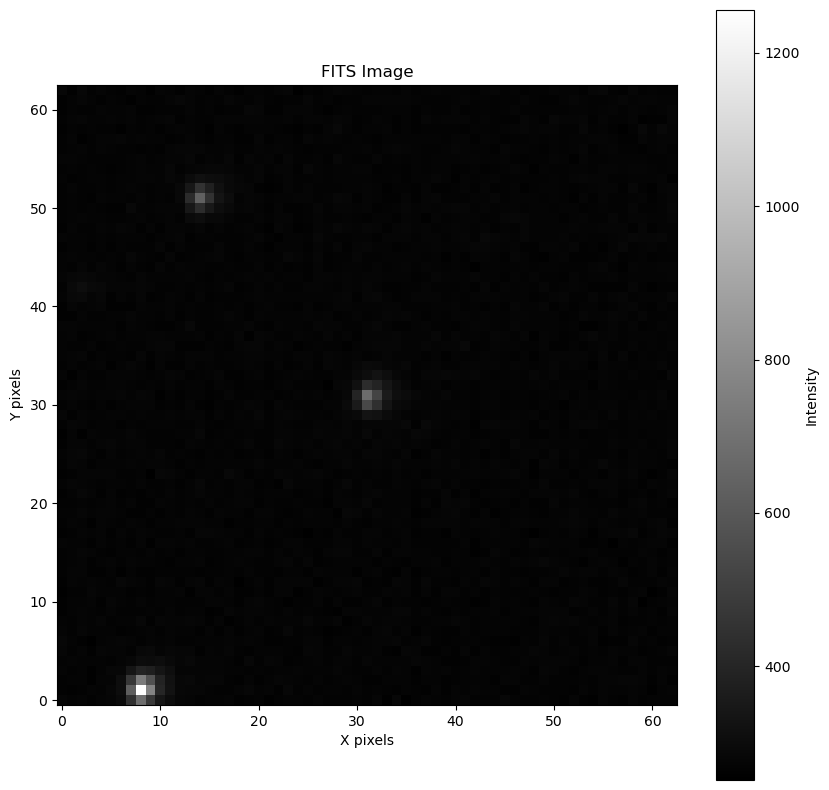

675.36255


In [86]:
def check_bright_center(image, patch_size=20, threshold=0.3):
    # Normalize to [0,1]
    img = cv2.normalize(image.astype(np.float32), None, 0, 1, cv2.NORM_MINMAX)

    h, w = img.shape
    cx, cy = w // 2, h // 2
    half = patch_size // 2

    # Extract center patch
    patch = img[cy-half:cy+half, cx-half:cx+half]

    # "Subtract from black" → distance from 0
    diff_from_black = cv2.absdiff(patch, 0)

    # Measure brightness
    brightness = cv2.mean(diff_from_black)[0]

    # Decision
    is_bright = brightness > threshold

    return is_bright


ztf_stamps = client.get_stamps(
        oid="ZTF23aanxrjm",
        survey="ztf"
)
hdu = ztf_stamps[0]
img = hdu.data

plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray', origin='lower')
plt.colorbar(label='Intensity')
plt.title('FITS Image')
plt.xlabel('X pixels')
plt.ylabel('Y pixels')
plt.show()
h, w = img.shape
cx, cy = w // 2, h // 2
print(img[cx][cy])

ZTF23aanxrjm False


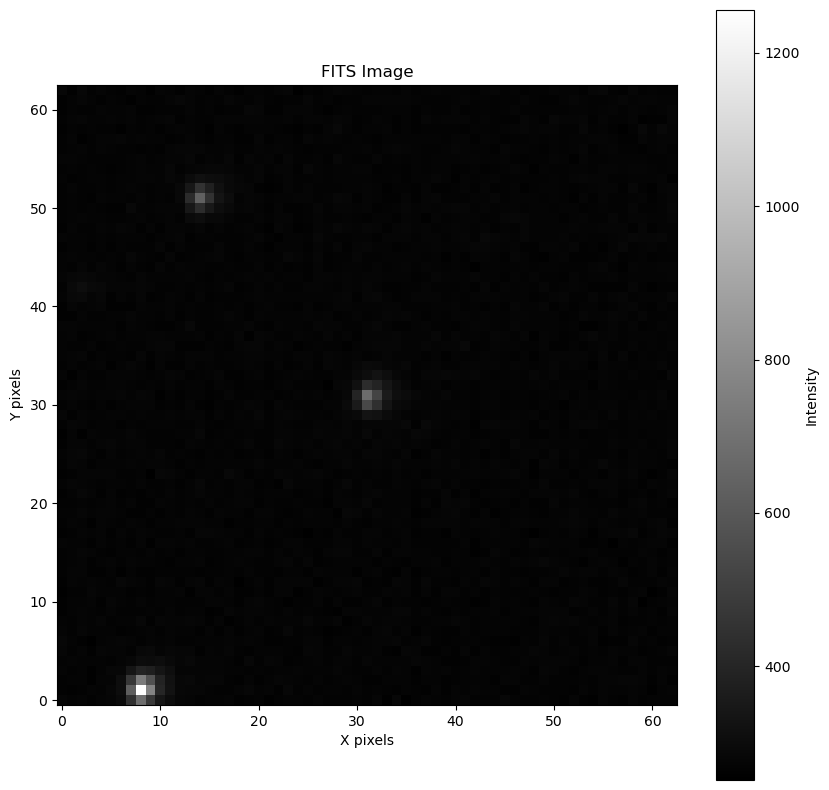

ZTF20abuxrsg False


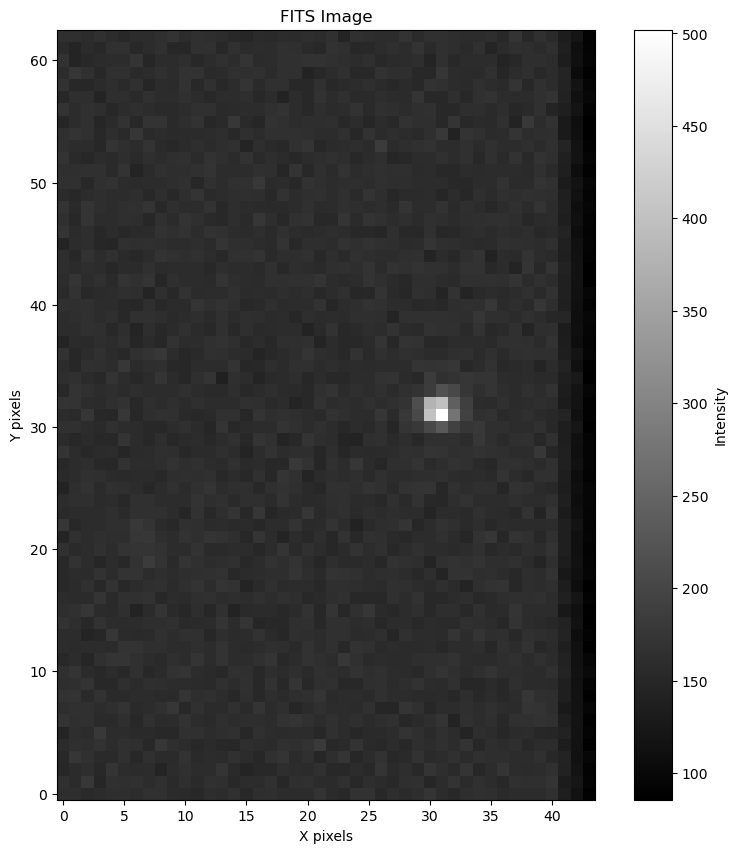

ZTF24abmyoit False


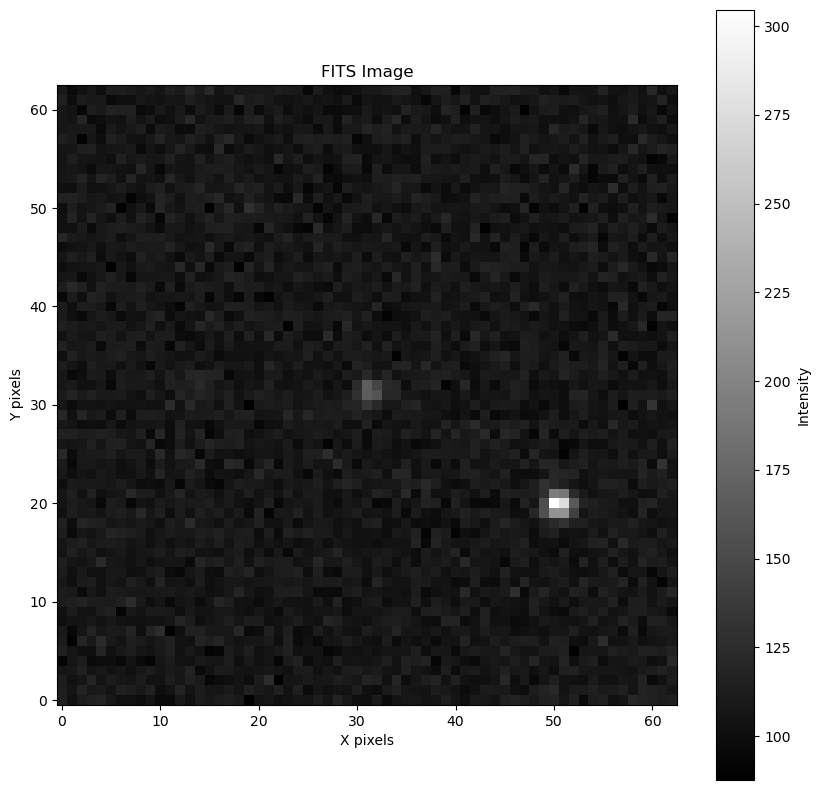

ZTF21abbuzez False


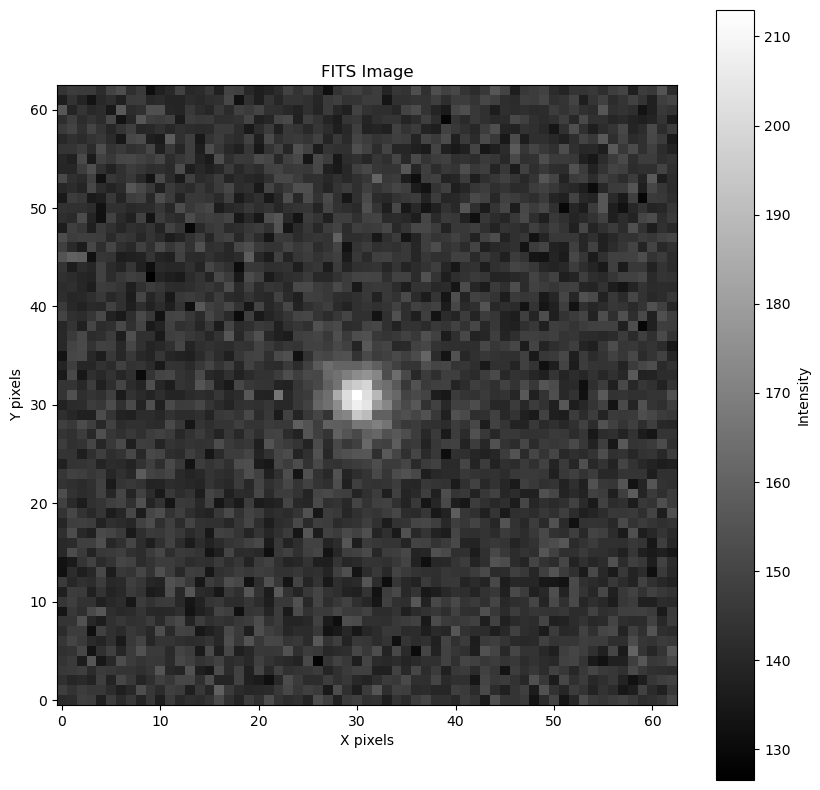

ZTF20abwtifz False


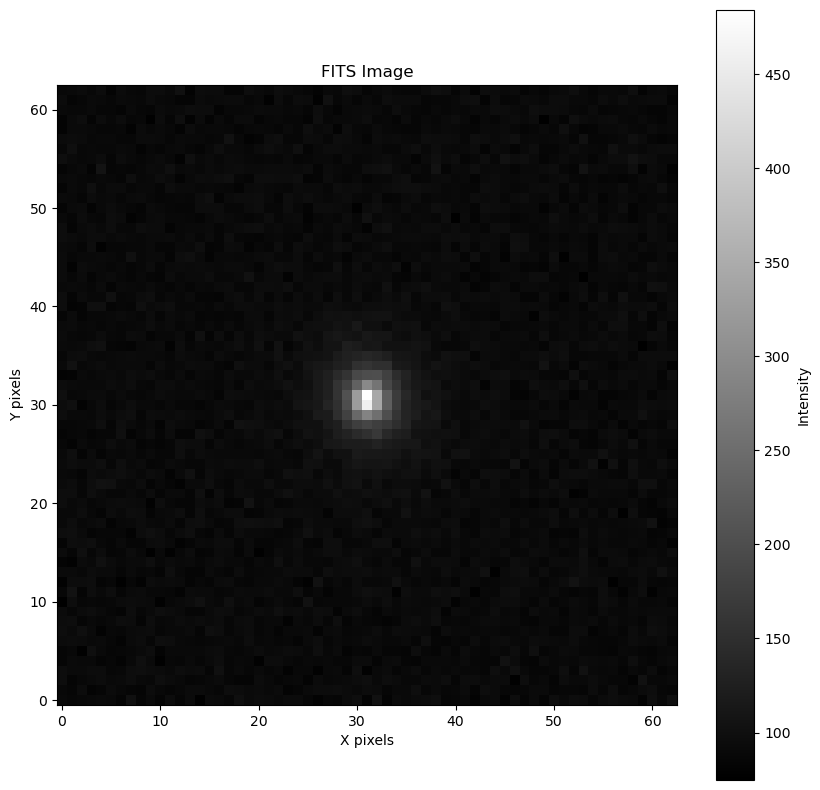

ZTF18adlwqsr False


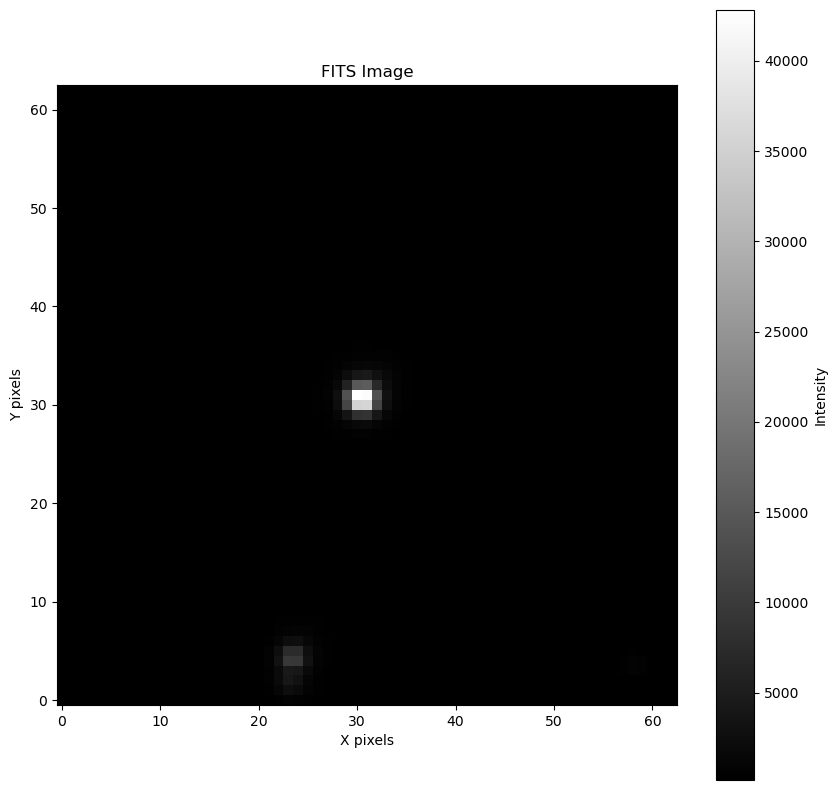

ZTF21aaoeuuz False


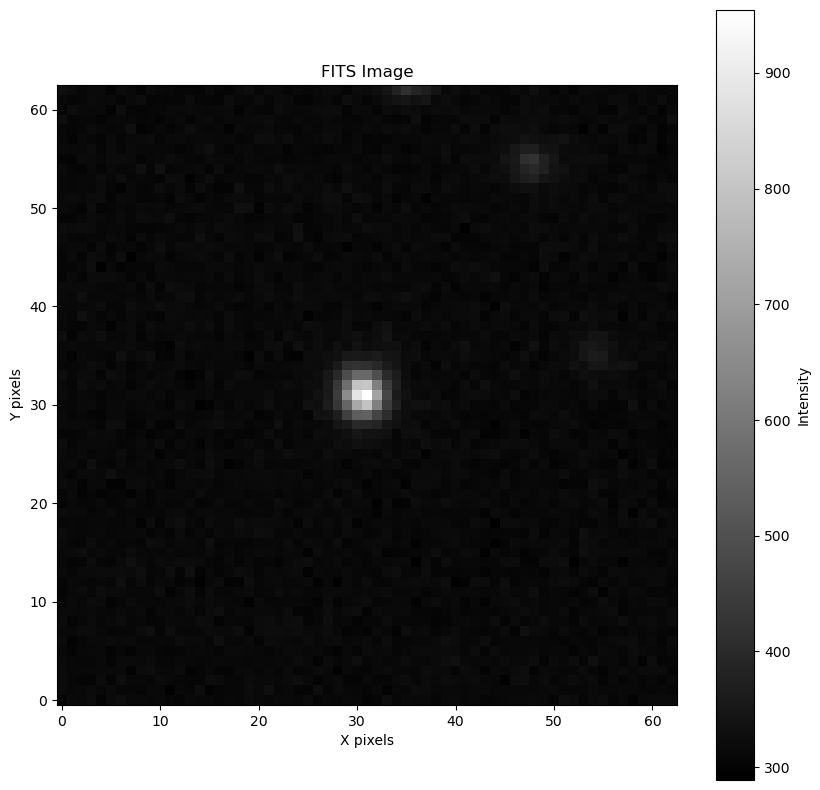

ZTF20acynqzb False


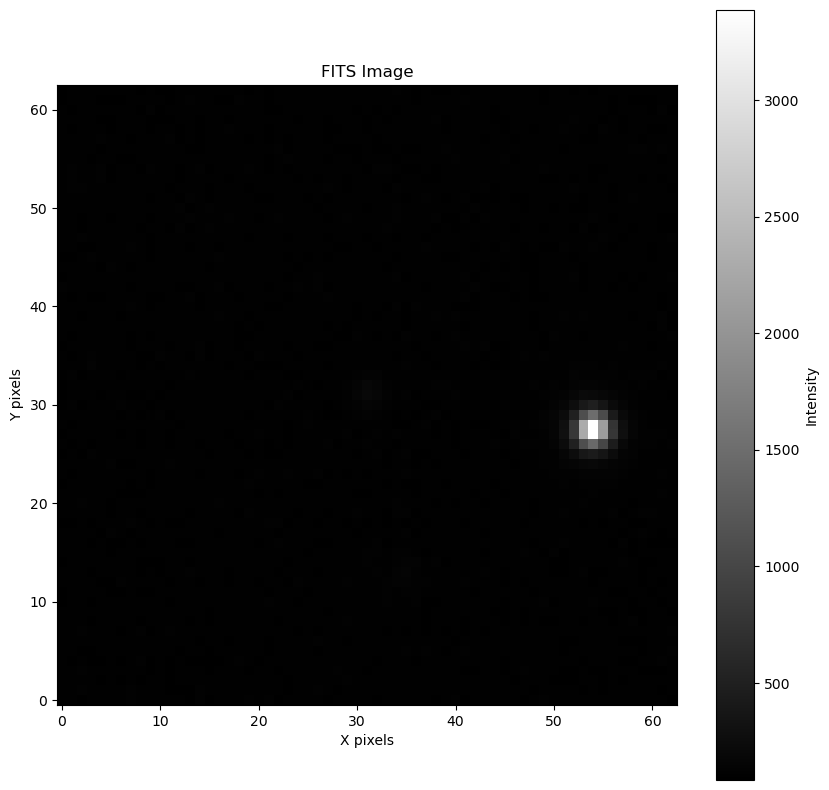

ZTF18abgmqhi False


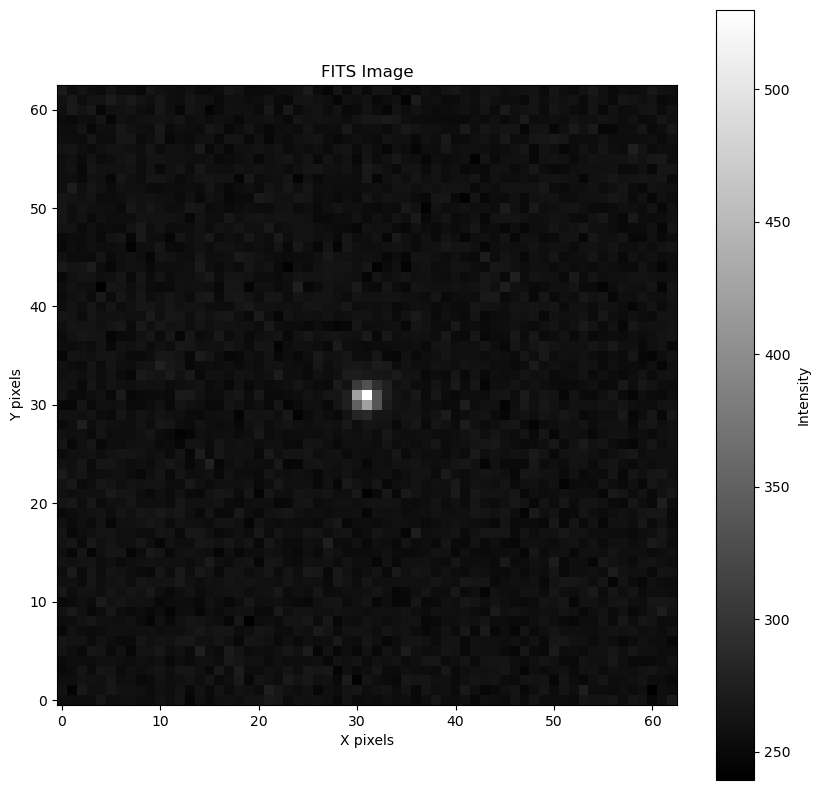

ZTF21abfxqfi False


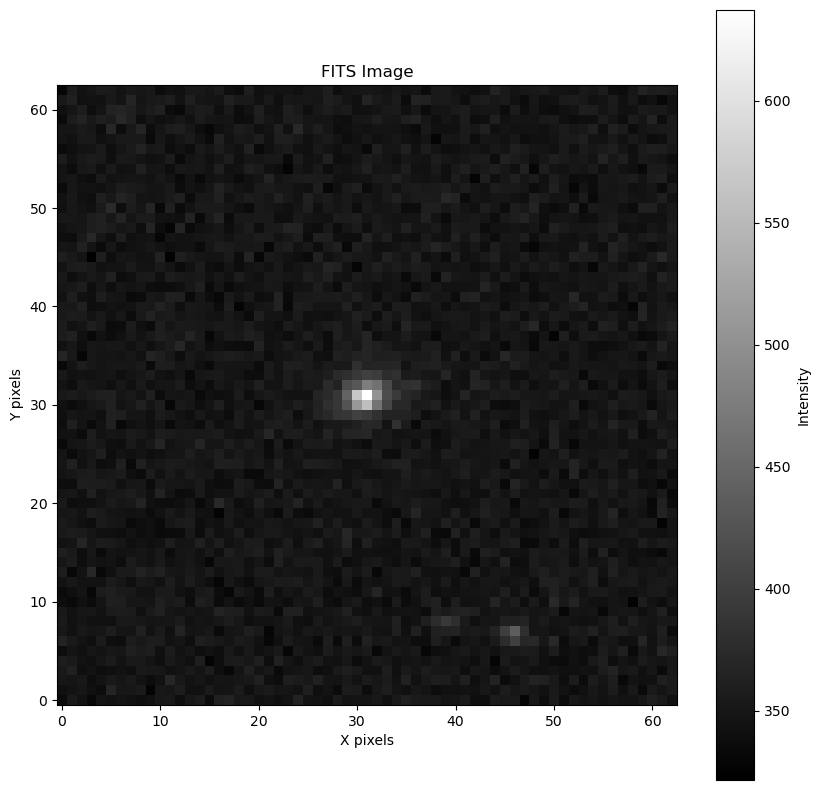

KeyboardInterrupt: 

KeyboardInterrupt: 

In [81]:
client = Alerce()

for i in range(500):
    oid = curves_data[i][0]
    """
    ra = curves_data[i][5]
    dec = curves_data[i][6]
    
    radius = 0.3
    cone_objects = client.catshtm_conesearch(ra,
                                    dec,
                                    radius,
                                    format="pandas")
    #print(cone_objects)
    print(oid, "Trash") if len(cone_objects) > 0 else print(oid, "Good")
    """
    ztf_stamps = client.get_stamps(
        oid=oid,
        survey="ztf"
    )
    hdu = ztf_stamps[0]
    
    image_data = hdu.data

    is_bright = check_bright_center(image_data)
    print(oid, is_bright)
    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image_data, cmap='gray', origin='lower')
    plt.colorbar(label='Intensity')
    plt.title('FITS Image')
    plt.xlabel('X pixels')
    plt.ylabel('Y pixels')
    plt.show()
    print("=" * 50)